# Análisis Exploratorio de Datos — Telco Customer Churn

**Elaborado por:** Nino Cabrera y Tiffany Mendoza


## 1. Introducción y contexto

### Objetivo general
Construir un modelo de clasificación binaria para predecir si un cliente de una empresa de telecomunicaciones abandonará el servicio (churn), aplicando prácticas de MLOps con FastAPI, Docker y CI/CD con GitHub Actions.

### Objetivos específicos
- Explorar y comprender la estructura del dataset, identificando distribución del target, valores faltantes y relaciones entre variables
- Preprocesar los datos usando scikit-learn con Pipelines, evitando data leakage
- Entrenar múltiples modelos con GridSearchCV y comparar su desempeño usando AUC-ROC, F1-score, Accuracy y Precision/Recall
- Desplegar el mejor modelo como API REST con FastAPI, contenerizada con Docker

### Contexto
El dataset **Telco Customer Churn** fue publicado en Kaggle y contiene registros de ~7,000 clientes de una empresa de telecomunicaciones con variables demográficas, de servicio y de facturación. El objetivo es predecir si un cliente se irá (`Churn = Yes`) o permanecerá (`Churn = No`). La retención de clientes es un problema crítico en telecomunicaciones, donde adquirir un nuevo cliente cuesta entre 5 y 25 veces más que retener uno existente.

## 2. Importación de librerías y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.dpi'] = 100

## 3. Dimensiones del conjunto de datos

Para comenzar, es importante conocer las dimensiones exactas del dataset y los tipos de cada columna.

In [3]:
df = pd.read_csv('../data/telco_churn.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> **Análisis:** Describir el número de registros, columnas y tipos de datos encontrados.

## 4. Variable objetivo

Se usará `Churn` como variable objetivo para predecir si un cliente abandona el servicio (`Churn = Yes`) o permanece (`Churn = No`).

In [4]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


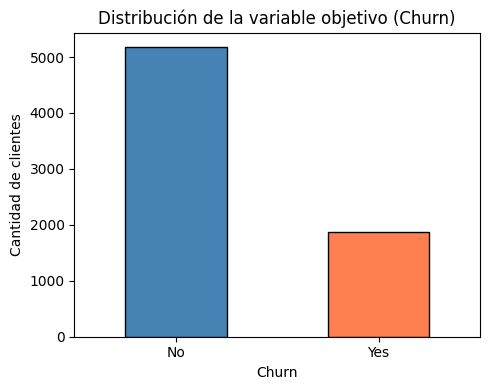

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Distribución de la variable objetivo (Churn)')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

> **Análisis:** Describir la distribución del target, el porcentaje de clientes que hacen churn y si existe desbalance de clases relevante para el modelado.

## 5. Inspección general

In [6]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
display(df.dtypes.to_frame(name='tipo').T)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
tipo,object,object,int64,object,object,int64,object,object,object,object,...,object,object,object,object,object,object,object,float64,object,object


> **Análisis:** Describir la composición general del dataset, identificar columnas de identificación, numéricas y categóricas.

## 6. Valores faltantes

In [8]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

resumen_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje (%)': porcentaje})
display(resumen_faltantes)

,faltantes,porcentaje (%)
customerID,0,0.00
DeviceProtection,0,0.00
TotalCharges,0,0.00
MonthlyCharges,0,0.00
PaymentMethod,0,0.00
PaperlessBilling,0,0.00
Contract,0,0.00
StreamingMovies,0,0.00
StreamingTV,0,0.00
TechSupport,0,0.00


> **Análisis:** Indicar si hay valores faltantes y la estrategia de imputación a seguir.

## 7. Medidas básicas

Las medidas de tendencia central como la media, mediana y desviación estándar muestran cómo se comportan las variables numéricas del dataset.

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,"7,043.00",0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75


> **Análisis:** Describir las variables numéricas, sus rangos, medias, medianas y desviaciones estándar. Señalar valores mínimos o máximos sospechosos.

## 8. Verificación de errores

El dataset de Telco Churn tiene una particularidad conocida: la columna `TotalCharges` viene como string en lugar de numérico, y los clientes nuevos (tenure=0) tienen `TotalCharges` vacío.

In [10]:
# Verificar tipo y valores problemáticos en TotalCharges
print('Tipo de TotalCharges:', df['TotalCharges'].dtype)

if df['TotalCharges'].dtype == object:
    espacios = df[df['TotalCharges'].str.strip() == ''].shape[0]
    print(f'Valores vacíos (espacios) en TotalCharges: {espacios}')

Tipo de TotalCharges: object
Valores vacíos (espacios) en TotalCharges: 11


In [11]:
# Convertir TotalCharges a numérico — los espacios vacíos se vuelven NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('NaN en TotalCharges tras conversión:', df['TotalCharges'].isnull().sum())

NaN en TotalCharges tras conversión: 11


In [12]:
# Los NaN corresponden a clientes con tenure=0 (clientes nuevos sin cargos)
# Se imputan con 0 porque es el valor lógicamente correcto
if 'tenure' in df.columns:
    display(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('NaN restantes en TotalCharges:', df['TotalCharges'].isnull().sum())

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


NaN restantes en TotalCharges: 0


In [13]:
# Convertir Churn a binario (0/1) para facilitar el análisis numérico
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Filas finales del dataset: {df.shape[0]}')
print('Churn convertido:', df['Churn'].value_counts().to_dict())

Filas finales del dataset: 7043
Churn convertido: {0: 5174, 1: 1869}


> **Análisis:** Describir los errores encontrados (TotalCharges como string, valores vacíos) y las correcciones aplicadas.

## 9. Métricas de dispersión (IQR)

El IQR (rango intercuartílico) permite identificar qué tan dispersos están los datos y detectar posibles valores atípicos.

In [14]:
cols_num = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[cols_num].quantile(0.25)
Q3 = df[cols_num].quantile(0.75)
IQR = Q3 - Q1

iqr_df = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR})
display(iqr_df)

,Q1,Q3,IQR
SeniorCitizen,0.00,0.00,0.00
tenure,9.00,55.00,46.00
MonthlyCharges,35.50,89.85,54.35
TotalCharges,398.55,"3,786.60","3,388.05"
Churn,0.00,1.00,1.00


> **Análisis:** Describir la dispersión de cada variable numérica e identificar cuáles tienen mayor variabilidad.

## 10. Análisis Univariado

### 10.1 Variables numéricas

Los histogramas permiten observar la distribución de cada variable numérica e identificar sesgos o valores atípicos.

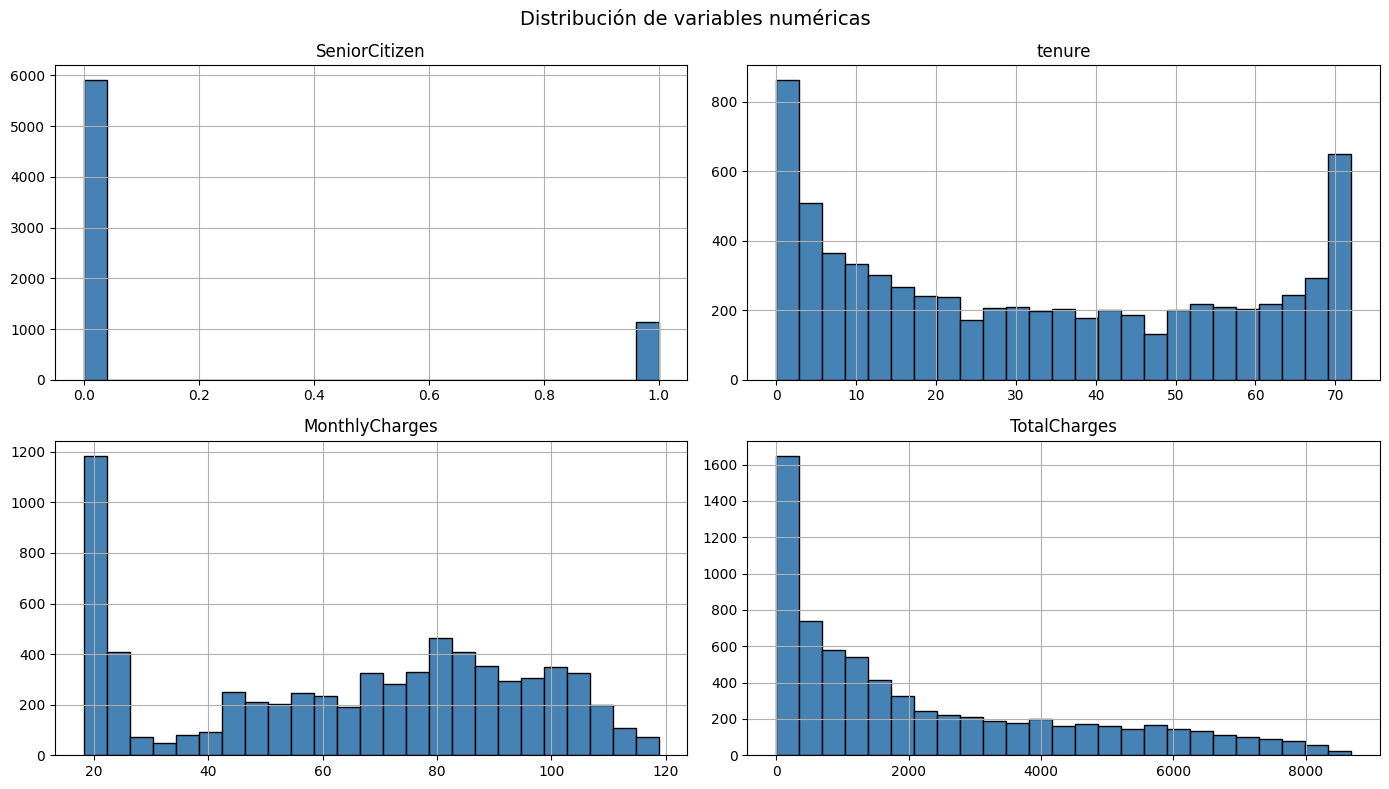

In [15]:
numericas = df.select_dtypes(include='number').drop(columns=['Churn']).columns

df[numericas].hist(bins=25, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

> **Análisis:** Describir la distribución de cada variable numérica (simetría, sesgos, concentración).

### 10.2 Variables categóricas

Se analizan las frecuencias de cada variable categórica para entender cómo están compuestas.

In [16]:
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas ({len(categoricas)}): {categoricas}')

Variables categóricas (16): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


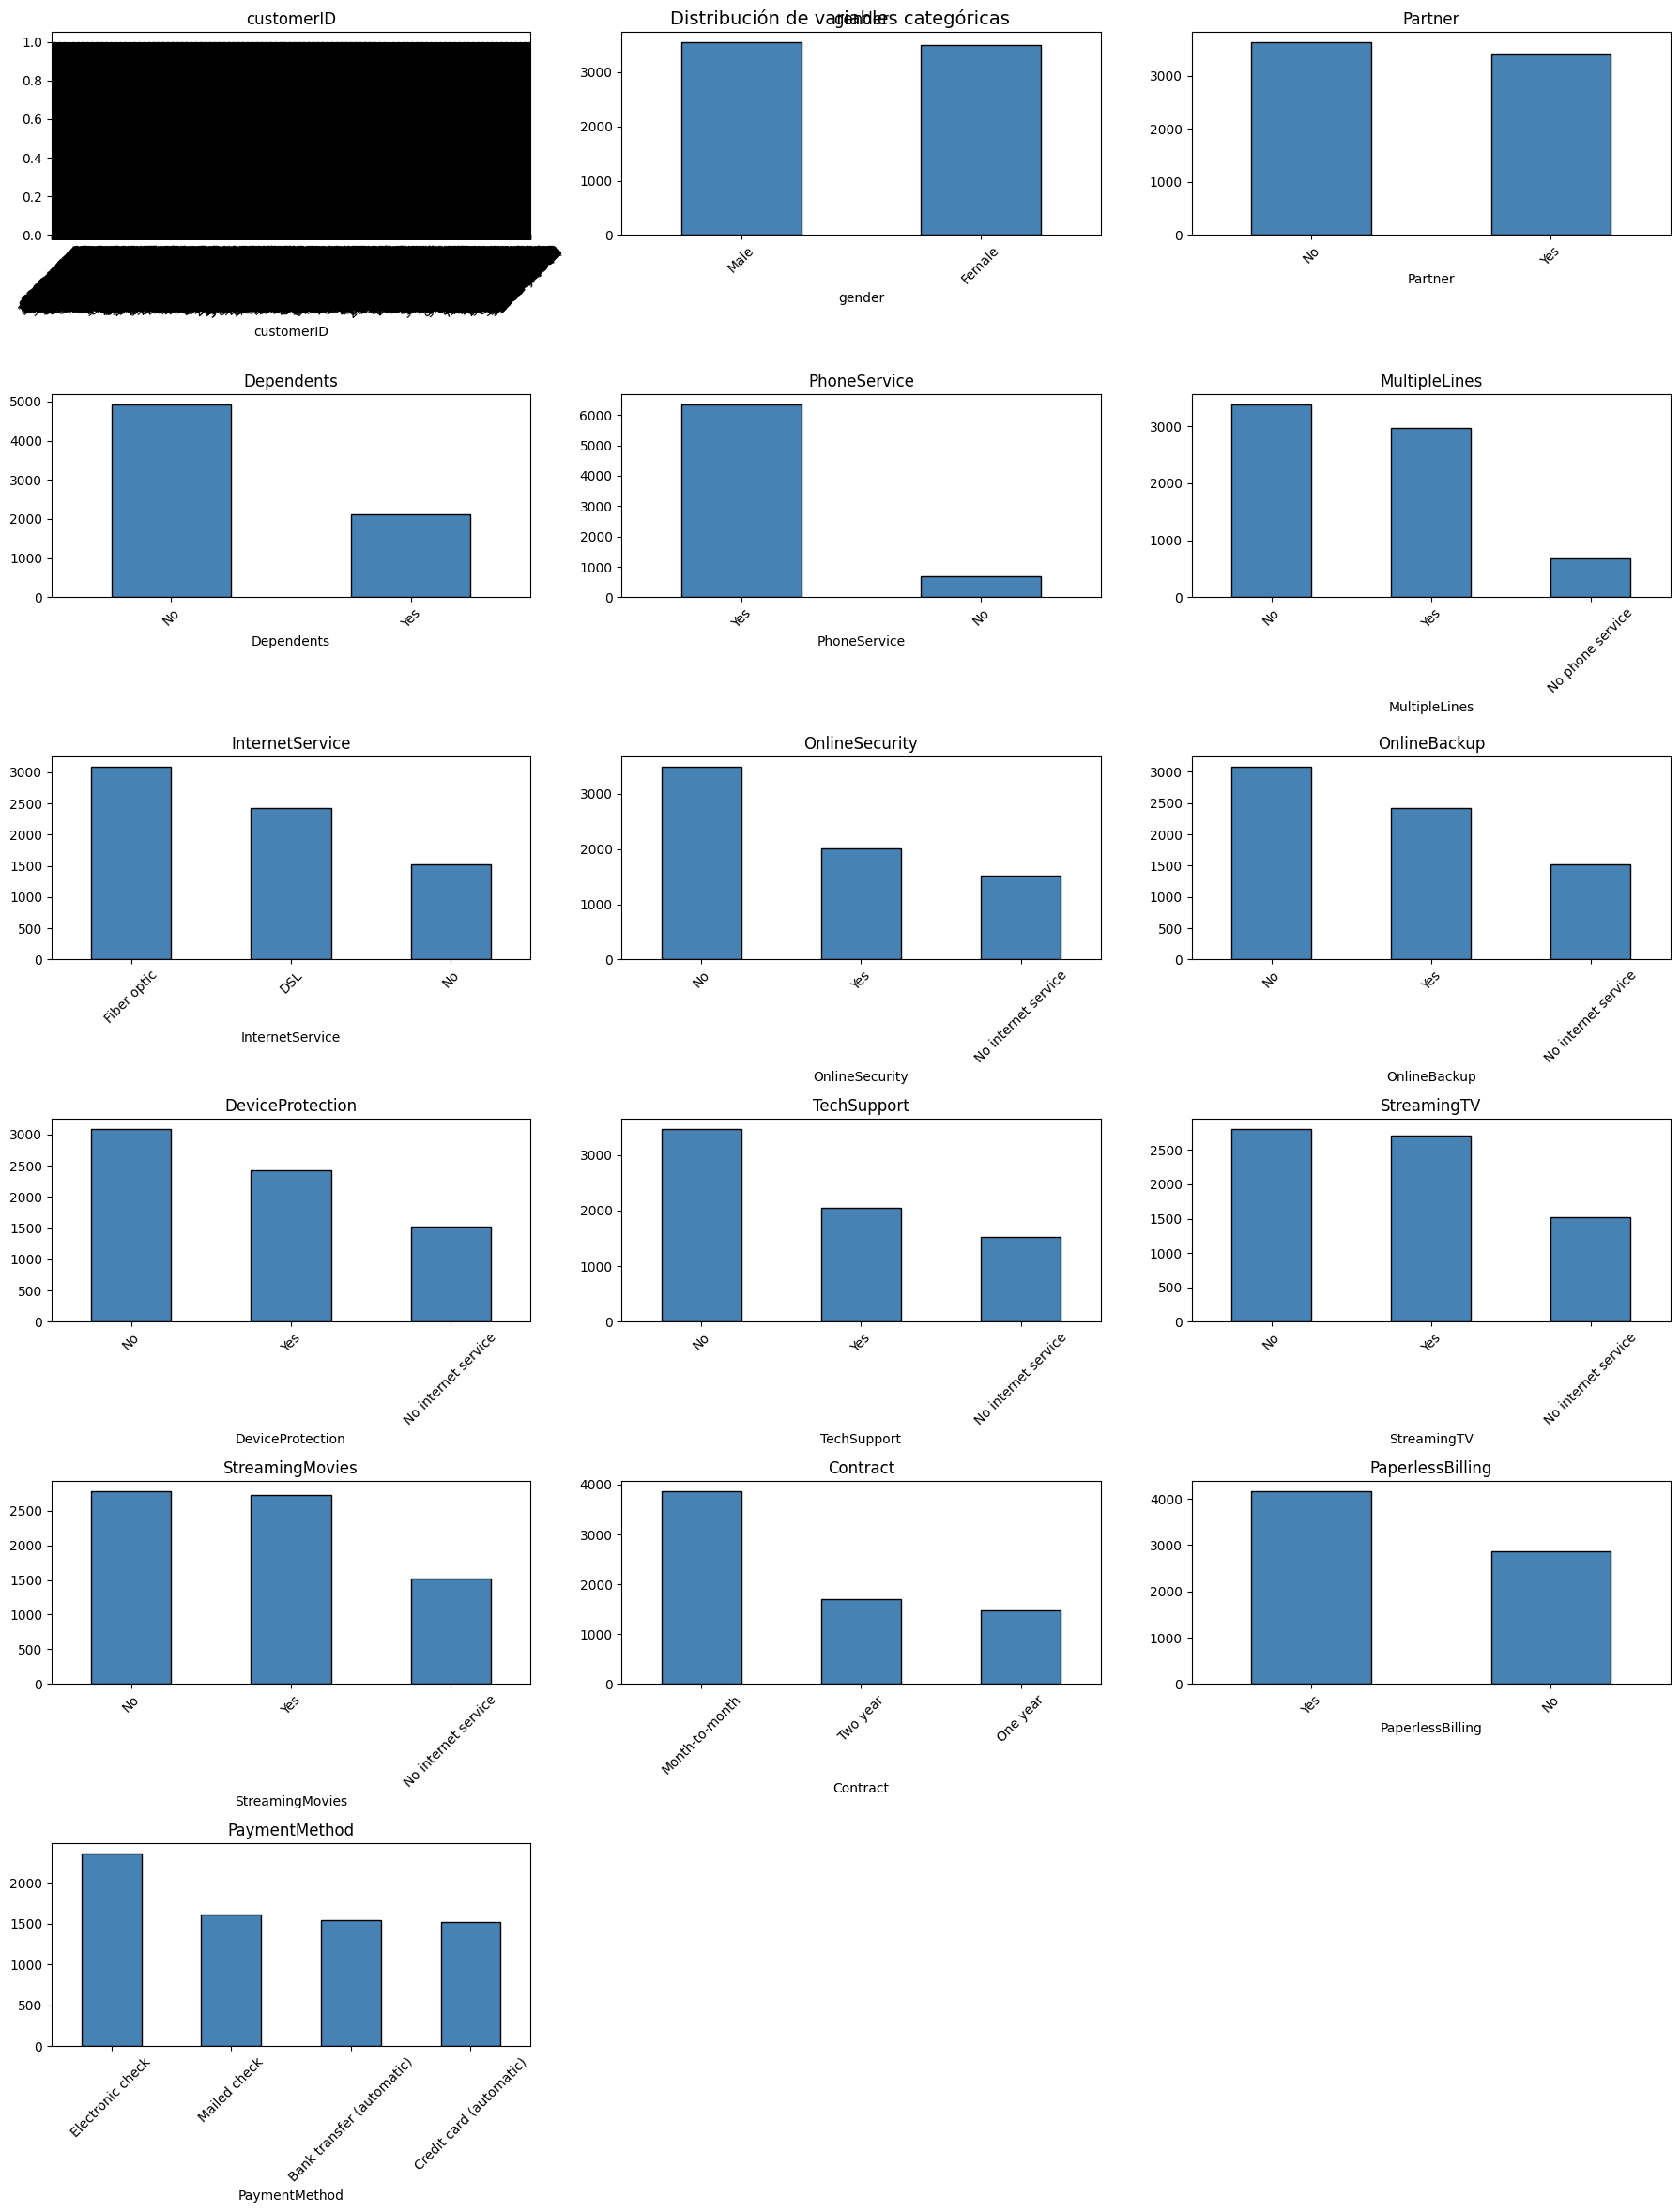

In [17]:
n_cols = 3
n_rows = (len(categoricas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

> **Análisis:** Describir la composición de cada variable categórica, señalar desbalances y categorías dominantes.

## 11. Análisis Multivariado

### 11.1 Boxplot por clase (Churn)

Se compara la distribución de cada variable numérica entre clientes que hacen churn (1) y los que no (0).

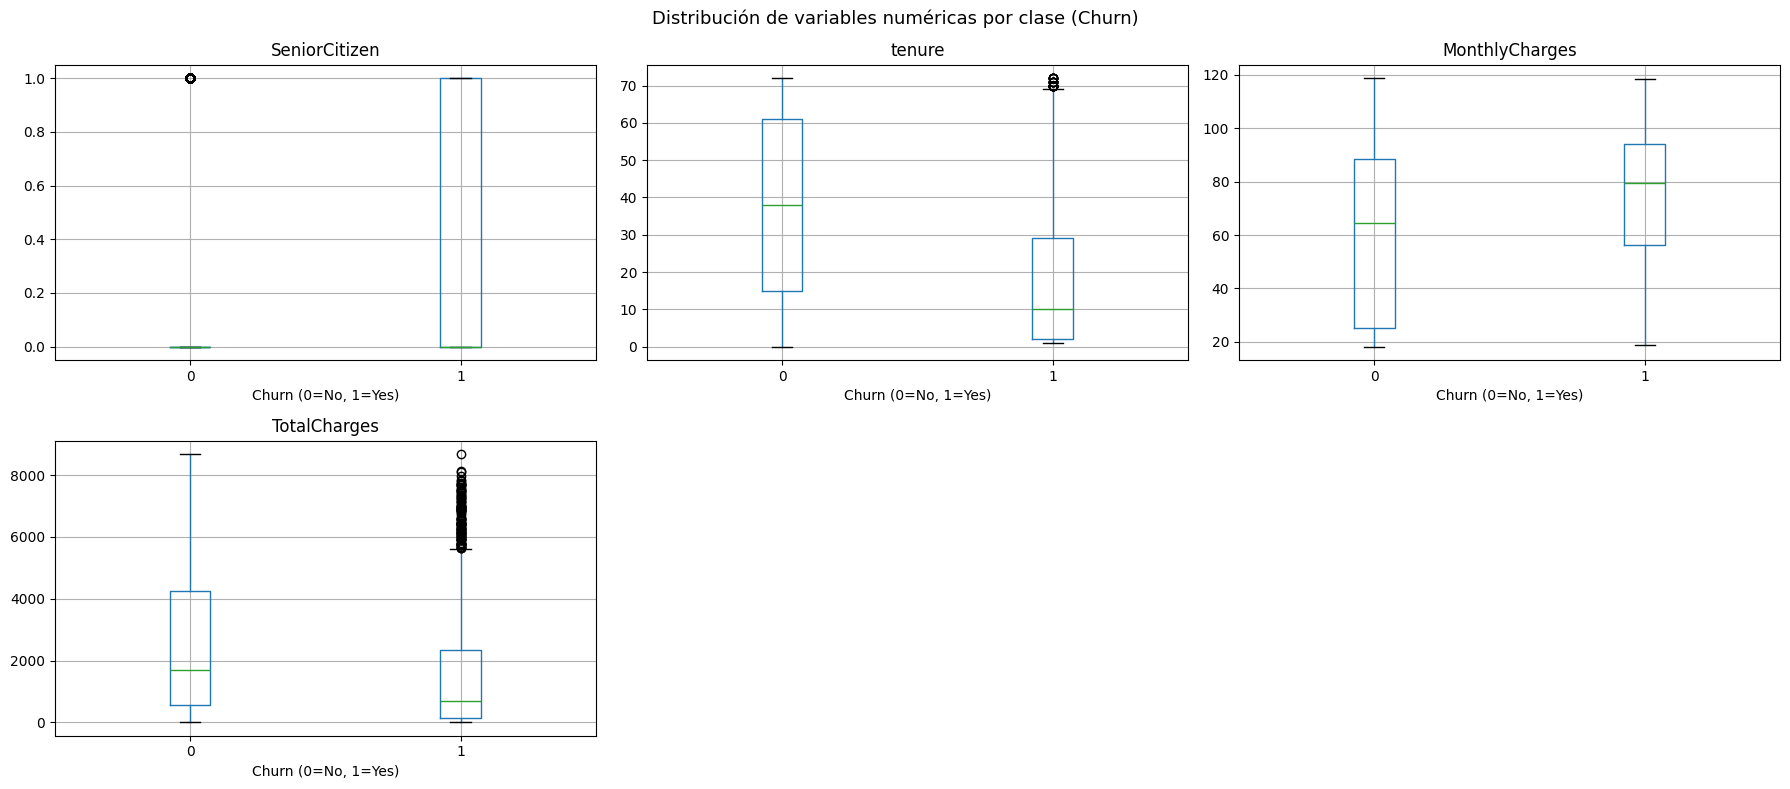

In [18]:
numericas = df.select_dtypes(include='number').drop(columns=['Churn']).columns

n_cols = 3
n_rows = (len(numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase (Churn)', fontsize=13)
plt.tight_layout()
plt.show()

> **Análisis:** Describir qué variables muestran diferencias claras entre clientes que hacen churn y los que no. Señalar cuáles tienen mayor poder discriminativo.

### 11.2 Tasa de churn por variable categórica

Se calcula la tasa de churn promedio dentro de cada categoría para identificar cuáles están más asociadas al abandono.

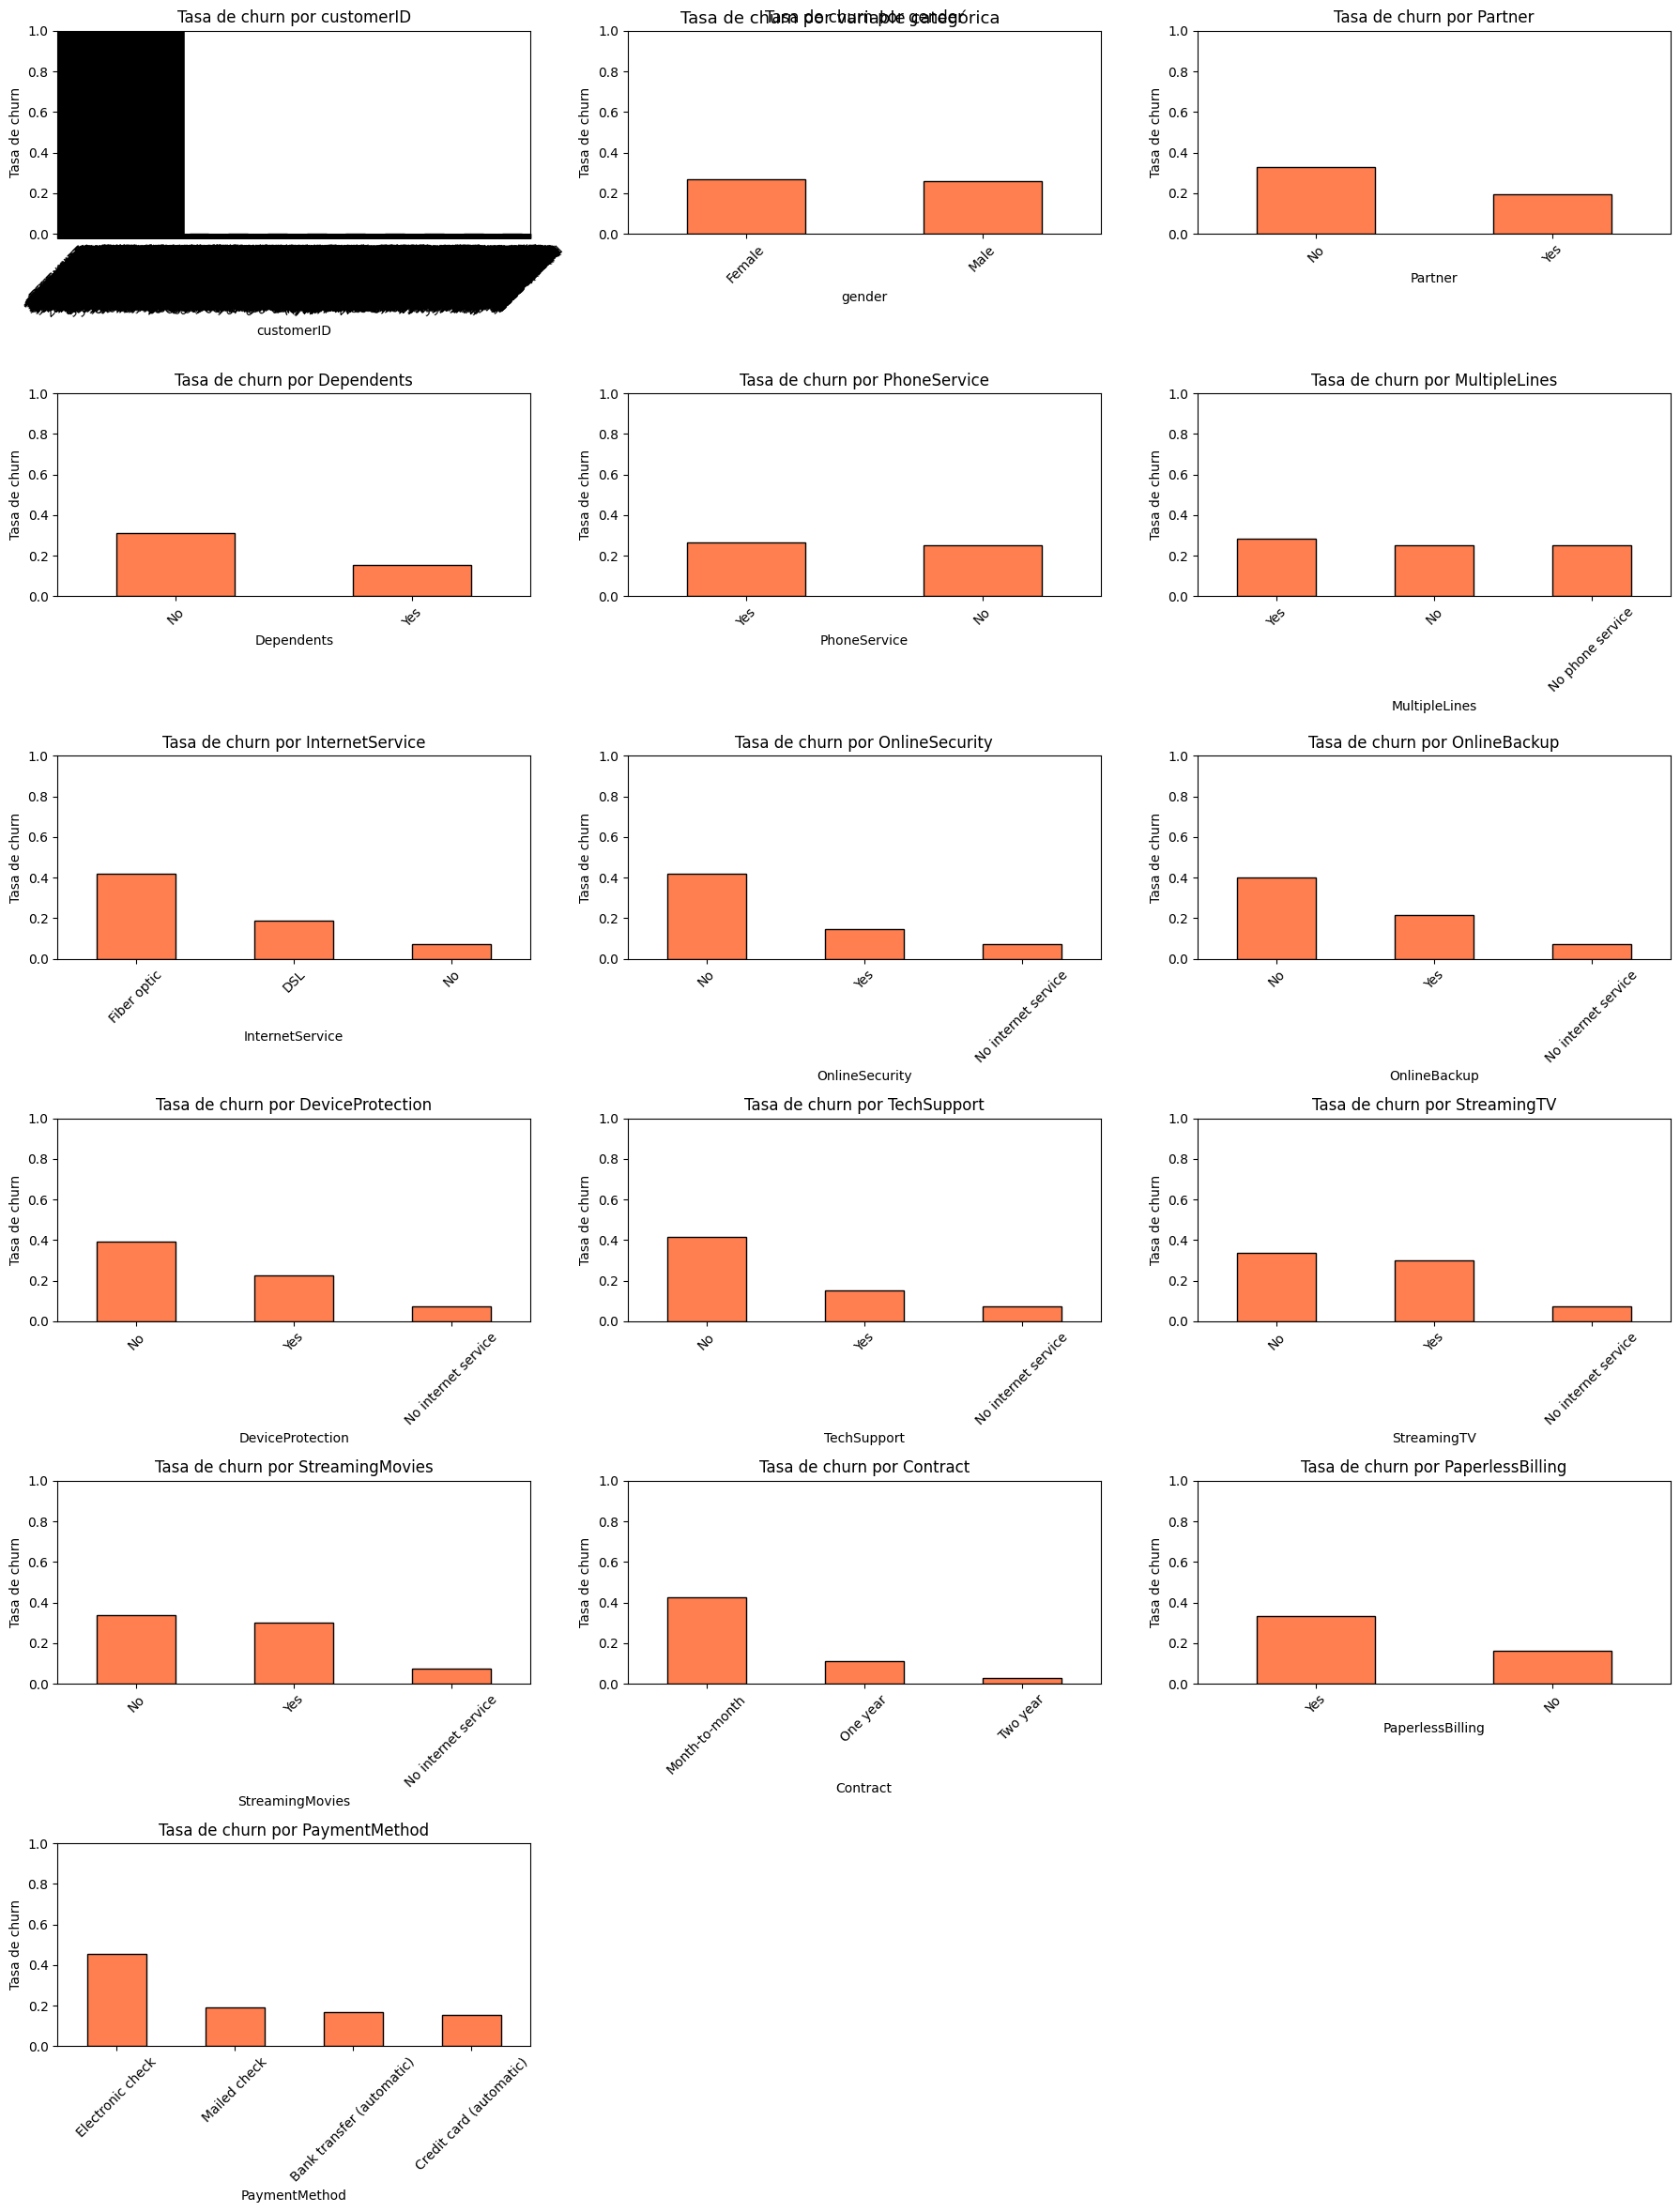

In [19]:
n_cols = 3
n_rows = (len(categoricas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Tasa de churn por {col}')
    axes[i].set_ylabel('Tasa de churn')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de churn por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

> **Análisis:** Identificar qué categorías tienen mayor tasa de churn y cuáles parecen ser factores de riesgo relevantes.

### 11.3 Correlación entre variables numéricas

La matriz de correlación muestra las relaciones lineales entre variables numéricas y la variable objetivo.

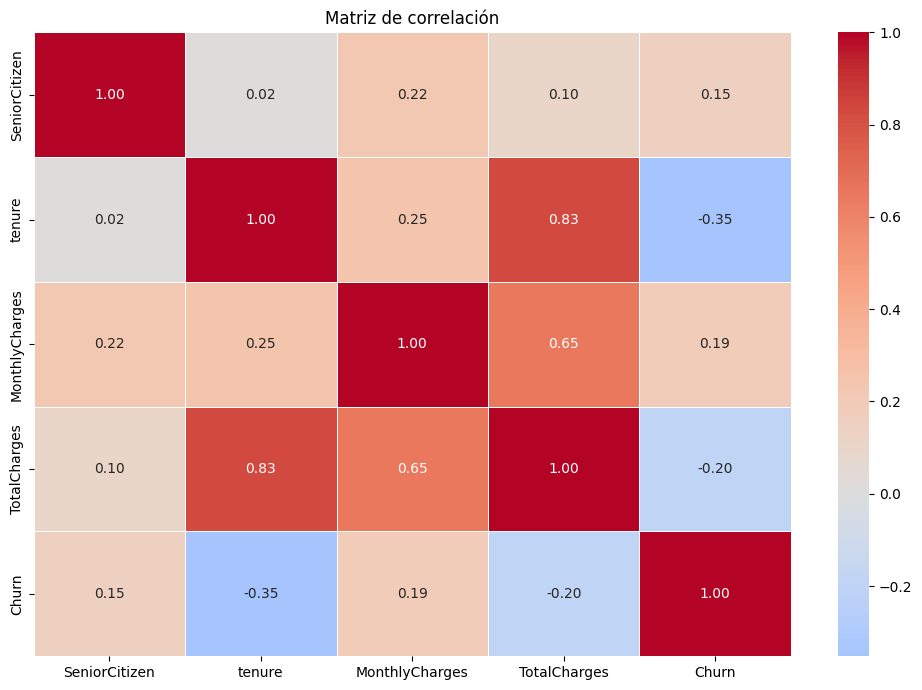

In [20]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

> **Análisis:** Describir las correlaciones más fuertes con Churn y entre variables predictoras. Señalar posible multicolinealidad (e.g. MonthlyCharges y TotalCharges).

### 11.4 Pairplot de variables numéricas clave

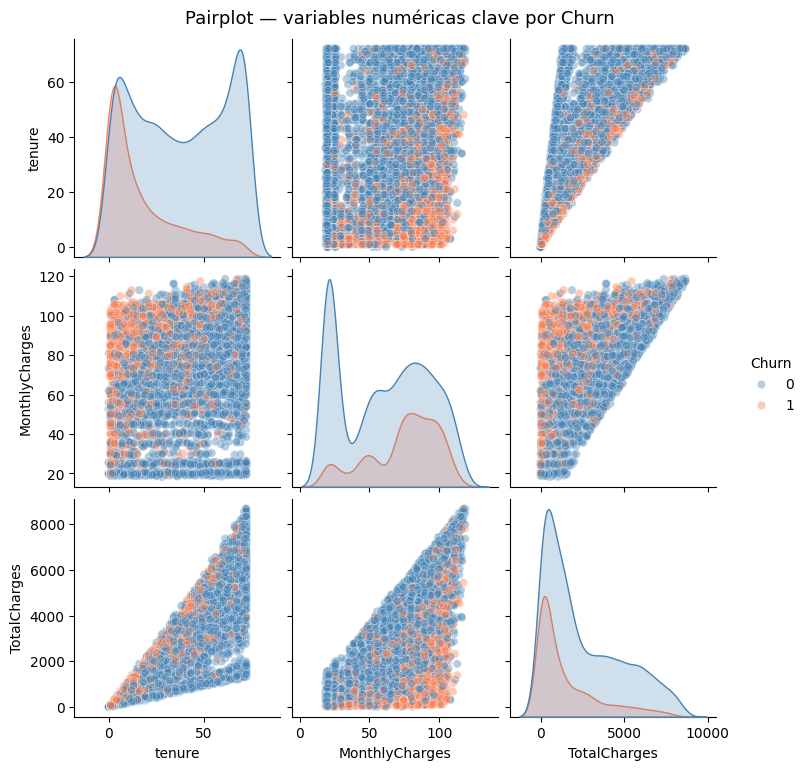

In [21]:
cols_pairplot = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
cols_existentes = [c for c in cols_pairplot if c in df.columns]

sns.pairplot(
    df[cols_existentes],
    hue='Churn',
    palette={0: 'steelblue', 1: 'coral'},
    plot_kws={'alpha': 0.4}
)
plt.suptitle('Pairplot — variables numéricas clave por Churn', y=1.02, fontsize=13)
plt.show()

> **Análisis:** Describir los patrones de separación entre clases en el espacio de variables numéricas clave.

## 12. Preprocesamiento final

Se eliminan columnas no útiles para el modelo, se identifican variables categóricas y numéricas, y se guarda el dataset limpio para el notebook de entrenamiento.

In [22]:
# Eliminar columna de identificación (no aporta al modelo)
cols_drop = ['customerID']
cols_drop = [c for c in cols_drop if c in df.columns]
df = df.drop(columns=cols_drop)

print(f'Shape final del dataset limpio: {df.shape}')
display(df.head())

Shape final del dataset limpio: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,"1,889.50",0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,"1,840.75",0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [23]:
# Separar predictoras y objetivo
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identificar tipos de columnas para el Pipeline del notebook 2
categoricas_model = X.select_dtypes(include='object').columns.tolist()
numericas_model = X.select_dtypes(include='number').columns.tolist()

print(f'Variables predictoras: {X.shape[1]}')
print(f'  Numéricas   ({len(numericas_model)}): {numericas_model}')
print(f'  Categóricas ({len(categoricas_model)}): {categoricas_model}')
print(f'\nVariable objetivo — distribución:')
print(y.value_counts())

Variables predictoras: 19
  Numéricas   (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variable objetivo — distribución:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
import os

os.makedirs('../data', exist_ok=True)
df.to_csv('../data/telco_churn_clean.csv', index=False)

print(f'✅ Dataset limpio guardado en data/telco_churn_clean.csv ({df.shape[0]} filas, {df.shape[1]} columnas)')

## Conclusiones del EDA

> Completar con los hallazgos principales:
> - Distribución del target y nivel de desbalance de clases
> - Variables numéricas y categóricas con mayor poder discriminativo
> - Errores encontrados en el dataset y transformaciones aplicadas
> - Variables que se descartaron y justificación
> - Decisiones de preprocesamiento que se llevarán al Pipeline del notebook 2